In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import importlib
import json
import sys

model_paths = [
    "/kaggle/input/models/leonidtikhanov/pinn-model/pytorch/default/4",
    ''
]

for p in model_paths:
    if Path(p).exists():
        sys.path.insert(0, p)
        break

import pinn_model
pinn_model = importlib.reload(pinn_model)

print(pinn_model.__file__)
print("run_experiment:", hasattr(pinn_model, "run_experiment"))

/kaggle/input/models/leonidtikhanov/pinn-model/pytorch/default/4/pinn_model.py
run_experiment: True


In [2]:
print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = "cuda"
    print("gpu:", torch.cuda.get_device_name(0))
else:
    device = "cpu"

work_dir = Path("/kaggle/working")
if not work_dir.exists():
    work_dir = Path(".")

print("device:", device)
print("work_dir:", work_dir)

torch version: 2.10.0+cu128
cuda available: True
gpu: Tesla T4
device: cuda
work_dir: /kaggle/working


In [3]:
seed = 0

runs = [
    {"run_id": 1, "task_name": "helmholtz1d", "m": 8, "dtype": "fp32", "adam_steps": 0, "lbfgs_steps": 1500},
    {"run_id": 2, "task_name": "helmholtz1d", "m": 8, "dtype": "fp64", "adam_steps": 0, "lbfgs_steps": 1500},
    {"run_id": 3, "task_name": "helmholtz1d", "m": 8, "dtype": "fp32", "adam_steps": 500, "lbfgs_steps": 1500},
    {"run_id": 4, "task_name": "helmholtz1d", "m": 8, "dtype": "fp64", "adam_steps": 500, "lbfgs_steps": 1500},
    {"run_id": 5, "task_name": "helmholtz1d", "m": 8, "dtype": "fp32", "adam_steps": 2000, "lbfgs_steps": 1500},
    {"run_id": 6, "task_name": "helmholtz1d", "m": 8, "dtype": "fp64", "adam_steps": 2000, "lbfgs_steps": 1500},
    {"run_id": 7, "task_name": "helmholtz1d", "m": 10, "dtype": "fp32", "adam_steps": 0, "lbfgs_steps": 1500},
    {"run_id": 8, "task_name": "helmholtz1d", "m": 10, "dtype": "fp64", "adam_steps": 0, "lbfgs_steps": 1500},
    {"run_id": 9, "task_name": "helmholtz1d", "m": 10, "dtype": "fp32", "adam_steps": 500, "lbfgs_steps": 1500},
    {"run_id": 10, "task_name": "helmholtz1d", "m": 10, "dtype": "fp64", "adam_steps": 500, "lbfgs_steps": 1500},
    {"run_id": 11, "task_name": "helmholtz1d", "m": 10, "dtype": "fp32", "adam_steps": 2000, "lbfgs_steps": 1500},
    {"run_id": 12, "task_name": "helmholtz1d", "m": 10, "dtype": "fp64", "adam_steps": 2000, "lbfgs_steps": 1500},
]

base_config = {
    "task_name": "helmholtz1d",
    "dtype": "fp32",
    "seed": seed,
    "device": device,
    "m": 8,
    "lambda_val": 1.0,
    "hid_size": 128,
    "num_layers": 4,
    "n_collocation": 5000,
    "n_bc": 2,
    "adam_steps": 0,
    "lbfgs_steps": 1500,
    "lr_adam": 5e-4,
    "resample_every": 0,
    "use_adam": False,
    "use_lbfgs": True,
    "lbfgs_tolerance_grad": 1e-12,
    "lbfgs_tolerance_change": 1e-14,
    "lbfgs_history_size": 100,
    "lbfgs_lr": 0.1,
    "lbfgs_line_search_fn": "strong_wolfe",
    "log_dir": str(work_dir / "runs" / "helmholtz_lbfgs_tmp"),
}

pd.DataFrame(runs)

,run_id,task_name,m,dtype,adam_steps,lbfgs_steps
0,1,helmholtz1d,8,fp32,0,1500
1,2,helmholtz1d,8,fp64,0,1500
2,3,helmholtz1d,8,fp32,500,1500
3,4,helmholtz1d,8,fp64,500,1500
4,5,helmholtz1d,8,fp32,2000,1500
5,6,helmholtz1d,8,fp64,2000,1500
6,7,helmholtz1d,10,fp32,0,1500
7,8,helmholtz1d,10,fp64,0,1500
8,9,helmholtz1d,10,fp32,500,1500
9,10,helmholtz1d,10,fp64,500,1500


In [4]:
all_summaries = []
all_histories = {}

for run in runs:
    config = base_config.copy()
    config.update(run)
    config["seed"] = seed
    config["use_adam"] = config["adam_steps"] > 0
    config["use_lbfgs"] = config["lbfgs_steps"] > 0
    config["log_dir"] = str(work_dir / "runs" / f"helmholtz_lbfgs_r{run['run_id']:02d}_m{run['m']}_{run['dtype']}_adam{run['adam_steps']}")

    run_dir = Path(config["log_dir"])
    summary_file = run_dir / "summary.json"
    metrics_file = run_dir / "metrics.csv"

    if summary_file.exists() and metrics_file.exists():
        with open(summary_file) as f:
            summary = json.load(f)
        history = pd.read_csv(metrics_file)
    else:
        history, summary = pinn_model.run_experiment(config)

    best = history.loc[history["l2_error"].idxmin()]
    summary["run_id"] = run["run_id"]
    summary["m"] = run["m"]
    summary["adam_steps_config"] = run["adam_steps"]
    summary["lbfgs_steps_config"] = run["lbfgs_steps"]
    summary["best_l2_error"] = float(best["l2_error"])
    summary["best_step"] = int(best["step"])
    summary["l2_ratio"] = float(summary["final_l2_error"] / summary["best_l2_error"])

    all_summaries.append(summary)
    all_histories[f"r{run['run_id']:02d}"] = history

    print(run["run_id"], run["m"], run["dtype"], run["adam_steps"], summary["final_l2_error"], summary["best_l2_error"], summary["time_sec"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


1 8 fp32 0 4.687134742736816 1.0168980360031128 19.79157018661499
2 8 fp64 0 2967304.82426884 0.9998590890430962 59.89629054069519
3 8 fp32 500 0.00021435217058751732 0.00021435217058751732 38.97390341758728
4 8 fp64 500 7.217639649334995 1.0120481539452901 90.99645137786865
5 8 fp32 2000 0.000699418771546334 9.030805813381448e-05 52.16482925415039
6 8 fp64 2000 0.0007741855997958159 0.00042351026042616445 148.55765843391418
7 10 fp32 0 5.747350692749023 1.0149681568145752 16.277892112731934
8 10 fp64 0 3.2562015901510386 0.9995512117851953 63.56511402130127
9 10 fp32 500 0.051498014479875565 0.01653413660824299 39.03663086891174
10 10 fp64 500 3.2562015925709984 1.0035130802412142 91.37158441543579
11 10 fp32 2000 0.002690007211640477 0.002690007211640477 52.38493037223816
12 10 fp64 2000 13.264213168182557 1.0035130802412142 148.383376121521


In [5]:
df = pd.DataFrame(all_summaries)
cols = [
    "run_id", "task_name", "m", "dtype", "seed",
    "adam_steps_config", "lbfgs_steps_config",
    "final_loss", "final_l2_error", "best_l2_error", "best_step", "l2_ratio", "time_sec", "log_dir",
]
df = df[cols]
df.to_csv(work_dir / "helmholtz_lbfgs_warmup_summary.csv", index=False)
df

,run_id,task_name,m,dtype,seed,adam_steps_config,lbfgs_steps_config,final_loss,final_l2_error,best_l2_error,best_step,l2_ratio,time_sec,log_dir
0,1,helmholtz1d,8,fp32,0,0,1500,1.964395e+05,4.687135e+00,1.016898,1,4.609248e+00,19.791570,/kaggle/working/runs/helmholtz_lbfgs_r01_m8_fp...
1,2,helmholtz1d,8,fp64,0,0,1500,1.319411e+13,2.967305e+06,0.999859,1,2.967723e+06,59.896291,/kaggle/working/runs/helmholtz_lbfgs_r02_m8_fp...
2,3,helmholtz1d,8,fp32,0,500,1500,4.023850e-03,2.143522e-04,0.000214,2000,1.000000e+00,38.973903,/kaggle/working/runs/helmholtz_lbfgs_r03_m8_fp...
3,4,helmholtz1d,8,fp64,0,500,1500,1.993749e+05,7.217640e+00,1.012048,1,7.131716e+00,90.996451,/kaggle/working/runs/helmholtz_lbfgs_r04_m8_fp...
4,5,helmholtz1d,8,fp32,0,2000,1500,2.050720e-03,6.994188e-04,0.000090,3100,7.744810e+00,52.164829,/kaggle/working/runs/helmholtz_lbfgs_r05_m8_fp...
5,6,helmholtz1d,8,fp64,0,2000,1500,2.426702e-03,7.741856e-04,0.000424,3300,1.828021e+00,148.557658,/kaggle/working/runs/helmholtz_lbfgs_r06_m8_fp...
6,7,helmholtz1d,10,fp32,0,0,1500,4.886058e+05,5.747351e+00,1.014968,1,5.662592e+00,16.277892,/kaggle/working/runs/helmholtz_lbfgs_r07_m10_f...
7,8,helmholtz1d,10,fp64,0,0,1500,4.822119e+05,3.256202e+00,0.999551,1,3.257664e+00,63.565114,/kaggle/working/runs/helmholtz_lbfgs_r08_m10_f...
8,9,helmholtz1d,10,fp32,0,500,1500,1.489290e-01,5.149801e-02,0.016534,1700,3.114648e+00,39.036631,/kaggle/working/runs/helmholtz_lbfgs_r09_m10_f...
9,10,helmholtz1d,10,fp64,0,500,1500,4.822119e+05,3.256202e+00,1.003513,1,3.244802e+00,91.371584,/kaggle/working/runs/helmholtz_lbfgs_r10_m10_f...


In [6]:
pivot = df.pivot_table(
    index=["m", "adam_steps_config"],
    columns="dtype",
    values=["final_l2_error", "best_l2_error"],
    aggfunc="first",
)
pivot.to_csv(work_dir / "helmholtz_lbfgs_warmup_pivot.csv")
pivot

best_l2_error           final_l2_error              
dtype                         fp32      fp64           fp32          fp64
m  adam_steps_config                                                     
8  0                      1.016898  0.999859       4.687135  2.967305e+06
   500                    0.000214  1.012048       0.000214  7.217640e+00
   2000                   0.000090  0.000424       0.000699  7.741856e-04
10 0                      1.014968  0.999551       5.747351  3.256202e+00
   500                    0.016534  1.003513       0.051498  3.256202e+00
   2000                   0.002690  1.003513       0.002690  1.326421e+01

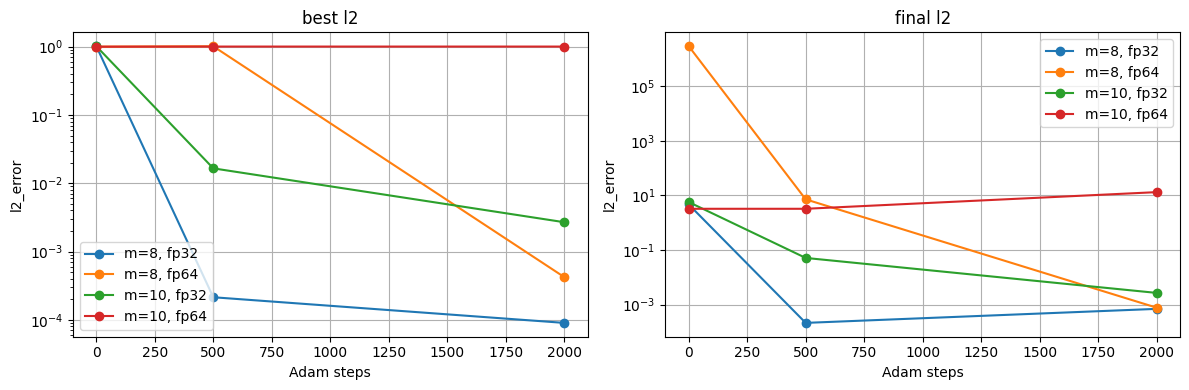

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for m in sorted(df["m"].unique()):
    part = df[df["m"] == m]
    for dtype in ["fp32", "fp64"]:
        cur = part[part["dtype"] == dtype].sort_values("adam_steps_config")
        label = f"m={m}, {dtype}"
        ax[0].plot(cur["adam_steps_config"], cur["best_l2_error"], marker="o", label=label)
        ax[1].plot(cur["adam_steps_config"], cur["final_l2_error"], marker="o", label=label)

ax[0].set_title("best l2")
ax[1].set_title("final l2")
for a in ax:
    a.set_xlabel("Adam steps")
    a.set_ylabel("l2_error")
    a.set_yscale("log")
    a.grid(True)
    a.legend()

fig.tight_layout()
plt.show()

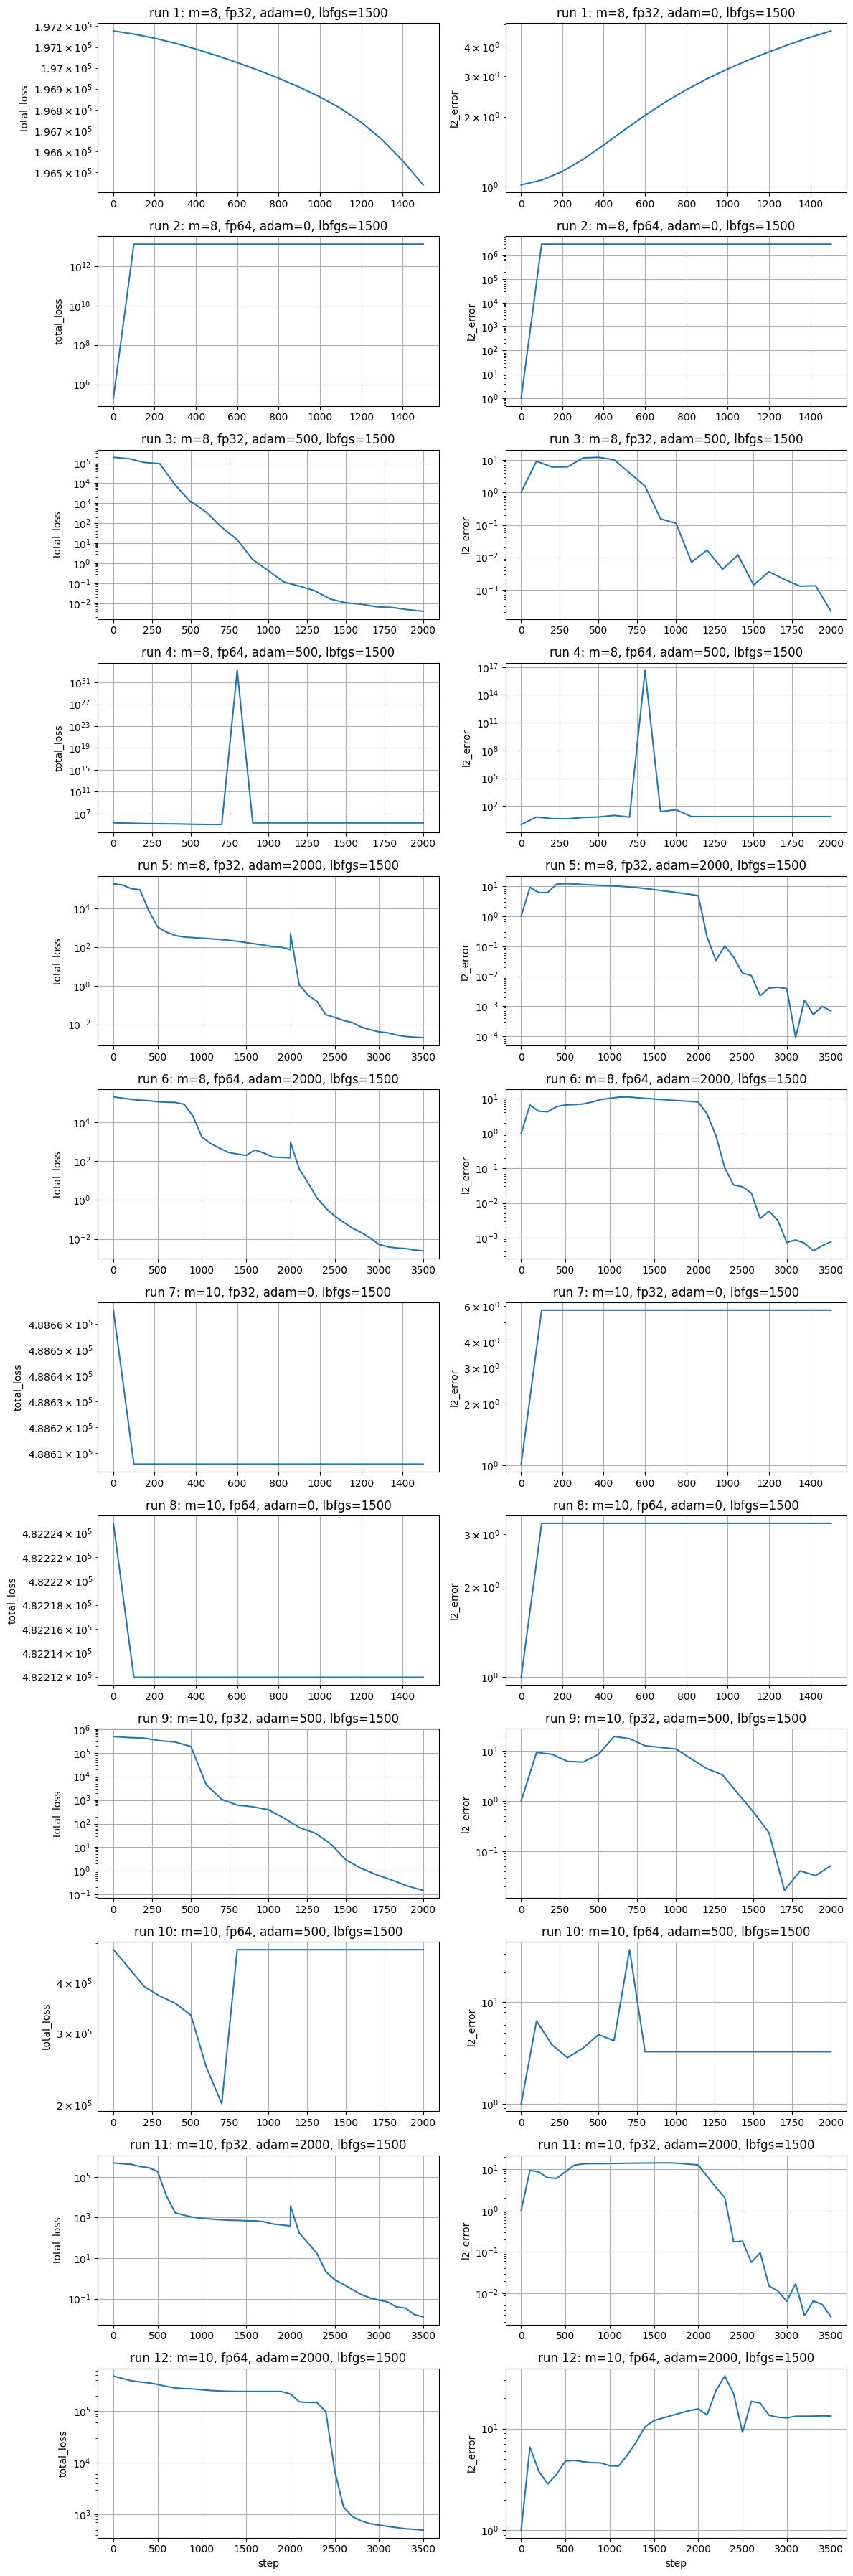

In [8]:
fig, ax = plt.subplots(len(runs), 2, figsize=(12, 3 * len(runs)))
ax = np.array(ax).reshape(len(runs), 2)

for i, run in enumerate(runs):
    key = f"r{run['run_id']:02d}"
    h = all_histories[key]
    title = f"run {run['run_id']}: m={run['m']}, {run['dtype']}, adam={run['adam_steps']}, lbfgs={run['lbfgs_steps']}"

    ax[i, 0].plot(h["step"], h["total_loss"])
    ax[i, 1].plot(h["step"], h["l2_error"])
    ax[i, 0].set_title(title)
    ax[i, 1].set_title(title)
    ax[i, 0].set_ylabel("total_loss")
    ax[i, 1].set_ylabel("l2_error")
    ax[i, 0].set_yscale("log")
    ax[i, 1].set_yscale("log")
    ax[i, 0].grid(True)
    ax[i, 1].grid(True)

for a in ax[-1]:
    a.set_xlabel("step")

fig.tight_layout()
plt.show()

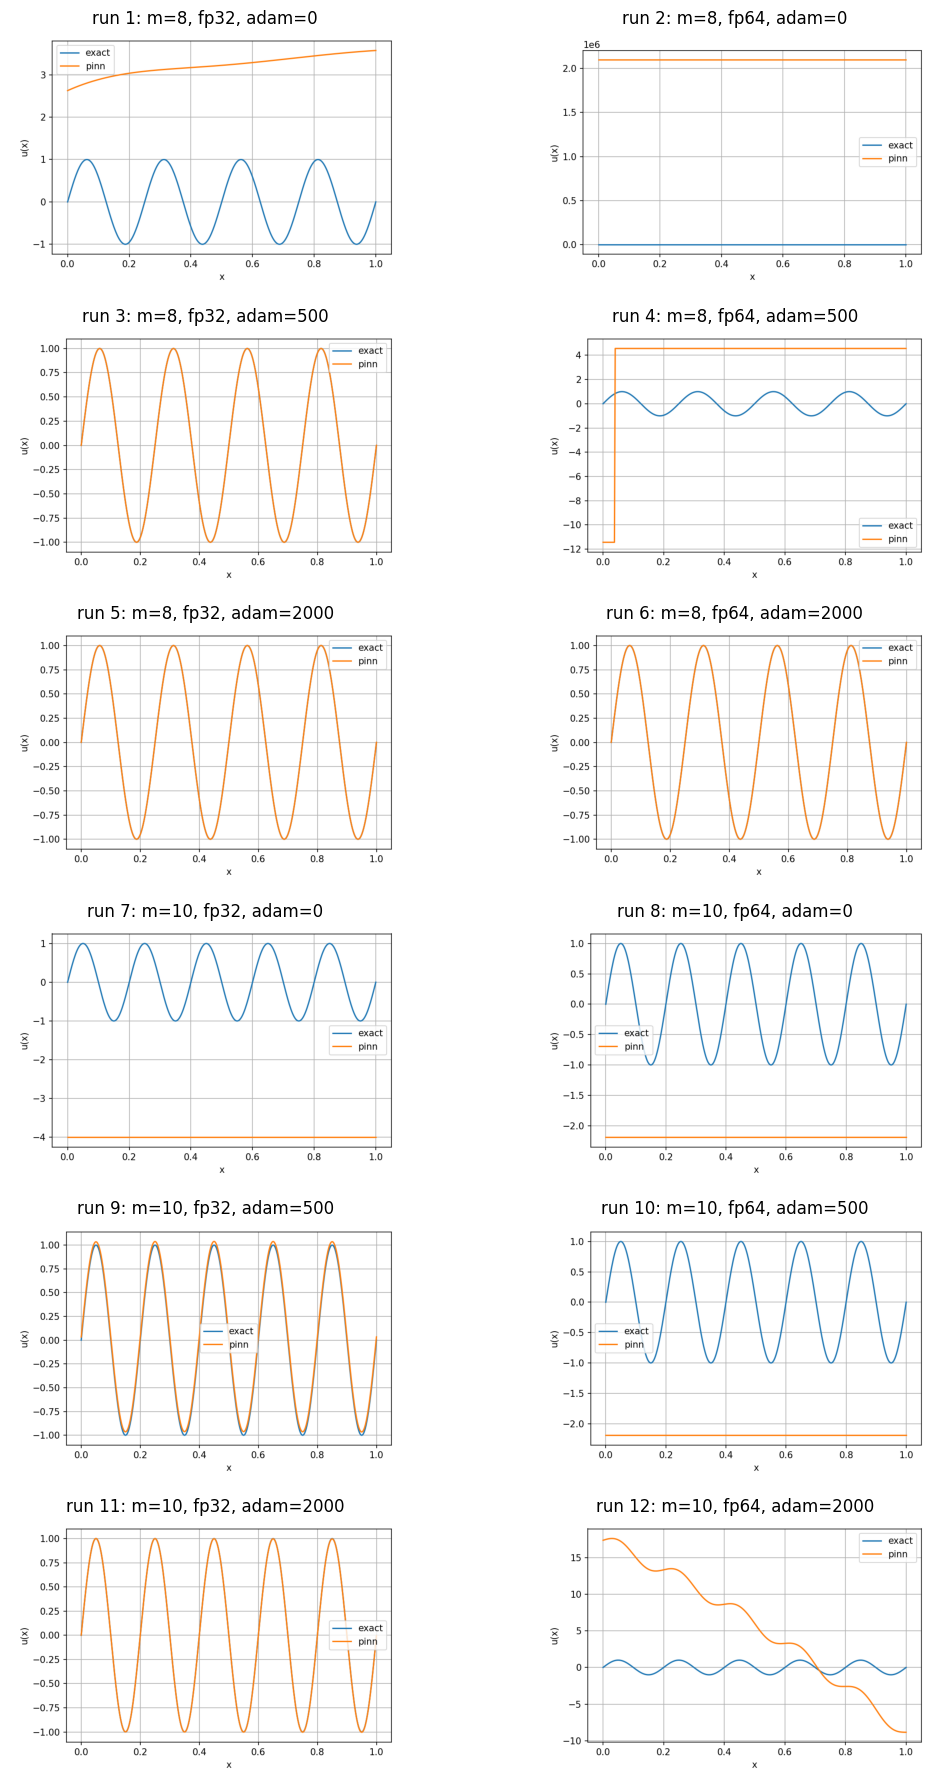

In [9]:
fig, ax = plt.subplots(6, 2, figsize=(12, 18))
ax = np.array(ax).reshape(6, 2)

for i, run in enumerate(runs):
    r = i // 2
    c = i % 2
    p = work_dir / "runs" / f"helmholtz_lbfgs_r{run['run_id']:02d}_m{run['m']}_{run['dtype']}_adam{run['adam_steps']}" / "solution_t1.png"
    ax[r, c].set_title(f"run {run['run_id']}: m={run['m']}, {run['dtype']}, adam={run['adam_steps']}")
    ax[r, c].axis("off")
    if p.exists():
        img = plt.imread(p)
        ax[r, c].imshow(img)

fig.tight_layout()
plt.show()